In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the Day 2 dataset
df = pd.read_csv('C:\\Users\\Richard\\Downloads\\Semester break\\Processed\\ai4i2020_featured.csv')

# Set a professional style
sns.set_style("ticks") # Clean, white background for reports
sns.set_context("talk") # Larger fonts for presentations

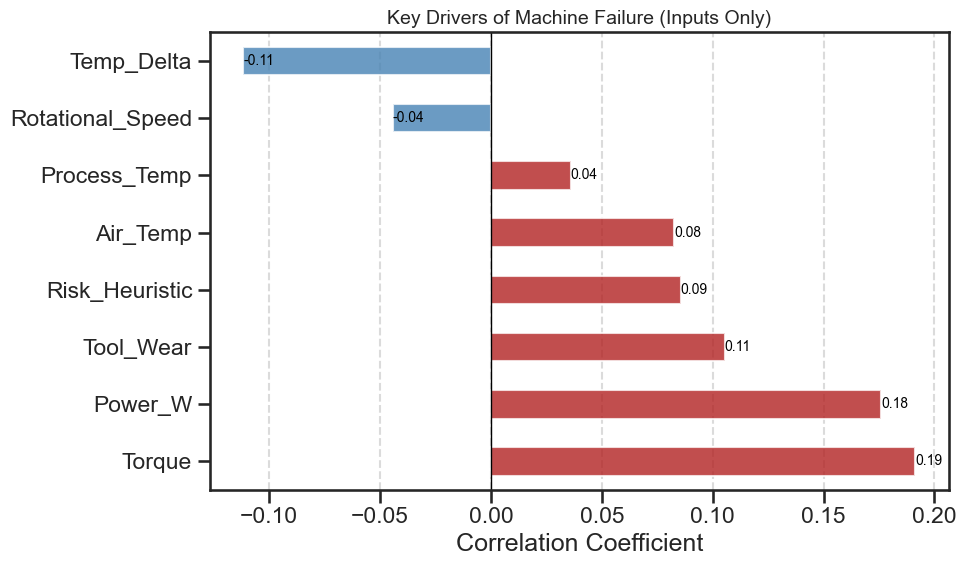

In [8]:
# ==========================================
# STEP 2: The "What Matters?" Chart (Curated)
# ==========================================

plt.figure(figsize=(10, 6))

# 1. Define the Input Features we want to test
# We EXCLUDE: 'UDI', 'Product_ID', and specific failure types like 'HDF', 'OSF'
# We INCLUDE: Raw Sensors + Your Physics Features
feature_list = [
    'Air_Temp', 
    'Process_Temp', 
    'Rotational_Speed', 
    'Torque', 
    'Tool_Wear',
    'Temp_Delta',       # Engineered
    'Power_W',          # Engineered
    'Risk_Heuristic',   # Engineered
    'Machine_Failure'   # Target
]

# 2. Calculate Correlation matrix only on this subset
corr = df[feature_list].corr()

# 3. Filter for target, sort, and drop the target itself
target_corr = corr['Machine_Failure'].drop('Machine_Failure').sort_values(ascending=False)

# 4. Plot
# Color logic: Red for positive correlation (Risk factor), Blue for negative (Protective factor)
colors = ['firebrick' if x > 0 else 'steelblue' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors, alpha=0.8)

plt.title('Key Drivers of Machine Failure (Inputs Only)', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels
for index, value in enumerate(target_corr):
    plt.text(value, index, f'{value:.2f}', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.savefig('C:\\Users\\Richard\\Downloads\\Semester break\\figures\\01_correlation_drivers.png', dpi=300)
plt.show()

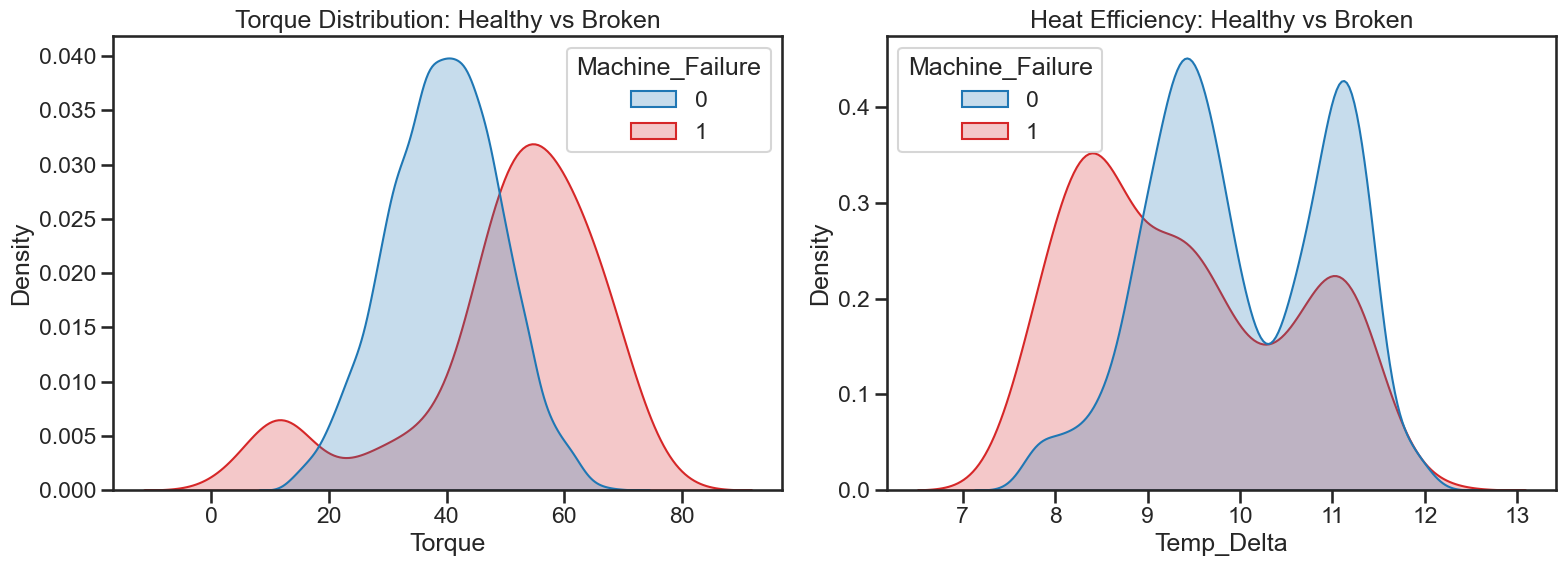

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Torque Distribution
sns.kdeplot(data=df, x='Torque', hue='Machine_Failure', fill=True, common_norm=False, palette=['tab:blue', 'tab:red'], ax=axes[0])
axes[0].set_title('Torque Distribution: Healthy vs Broken')

# Plot 2: Your Physics Feature (Temp Delta)
sns.kdeplot(data=df, x='Temp_Delta', hue='Machine_Failure', fill=True, common_norm=False, palette=['tab:blue', 'tab:red'], ax=axes[1])
axes[1].set_title('Heat Efficiency: Healthy vs Broken')

# Save
plt.tight_layout()
plt.savefig('C:\\Users\\Richard\\Downloads\\Semester break\\figures\\02_distribution_shift.png', dpi=300)
plt.show()

If the Red curve is completely separated from the Blue curve, the problem is easy. If they overlap heavily, the problem is hard (and that's why we need Machine Learning, not just simple If/Then rules)

C:\Users\Richard\AppData\Local\Temp\ipykernel_10396\4052324944.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_profile = df.groupby('Power_Bin')['Machine_Failure'].mean() * 100 # Convert to %


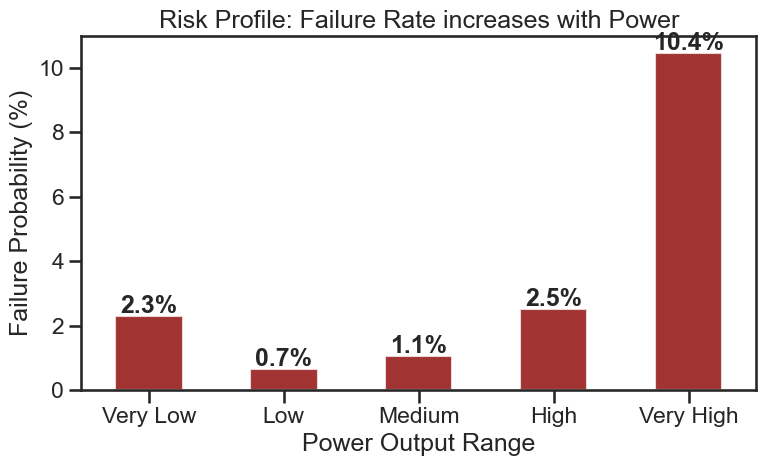

In [10]:
# Create bins for Power
# We use qcut to split data into 5 equal-sized buckets (quintiles)
df['Power_Bin'] = pd.qcut(df['Power_W'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Calculate failure rate per bin
risk_profile = df.groupby('Power_Bin')['Machine_Failure'].mean() * 100 # Convert to %

plt.figure(figsize=(8, 5))
risk_profile.plot(kind='bar', color='darkred', alpha=0.8)

plt.title('Risk Profile: Failure Rate increases with Power')
plt.ylabel('Failure Probability (%)')
plt.xlabel('Power Output Range')
plt.xticks(rotation=0)

# Add value labels on top of bars
for i, v in enumerate(risk_profile):
    plt.text(i, v + 0.1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('C:\\Users\\Richard\\Downloads\\Semester break\\figures\\03_risk_profile.png', dpi=300)
plt.show()

C:\Users\Richard\AppData\Local\Temp\ipykernel_10396\3935569503.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Power_Bin', y='Rotational_Speed', palette='Blues', ax=axes[0])
C:\Users\Richard\AppData\Local\Temp\ipykernel_10396\3935569503.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Power_Bin', y='Temp_Delta', palette='Reds', ax=axes[1])


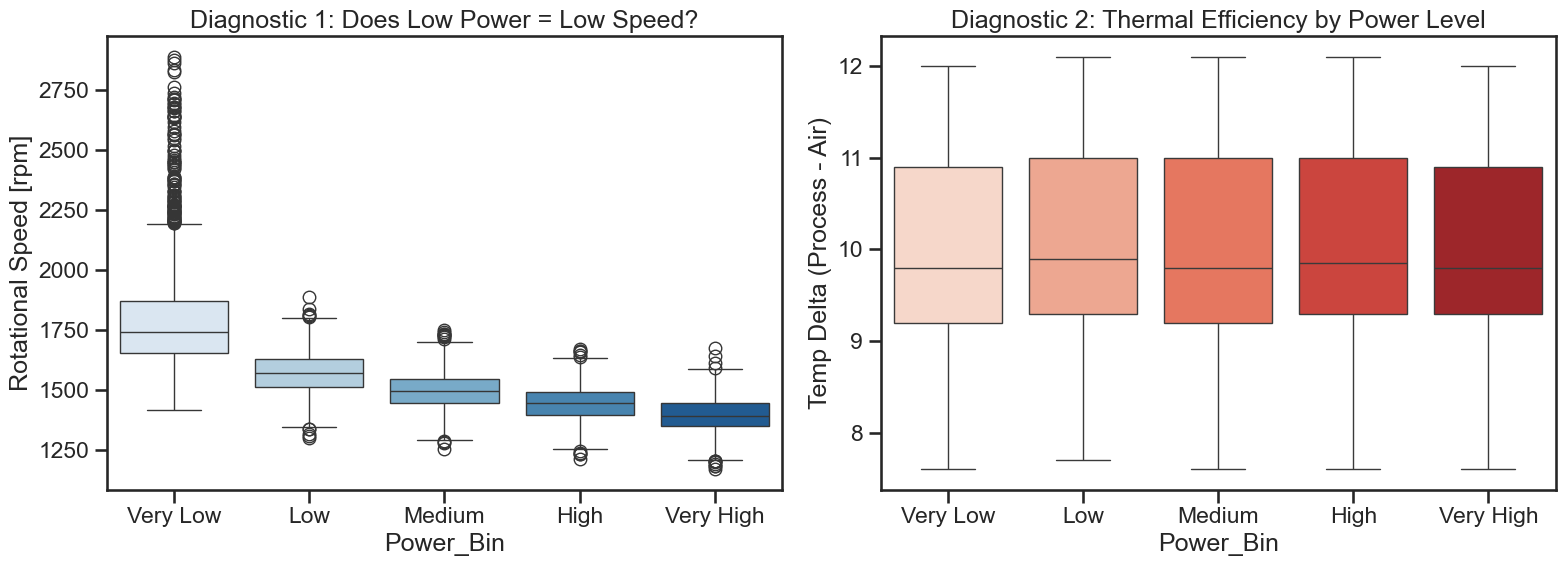

--- THE EVIDENCE ---
           Rotational_Speed  Temp_Delta  Machine_Failure
Power_Bin                                               
Very Low          1787.4270     9.96345           0.0230
Low               1571.0120    10.03085           0.0065
Medium            1496.0915    10.01345           0.0105
High              1444.4340    10.02335           0.0250
Very High         1394.9160     9.97205           0.1045


In [12]:
# ==========================================
# INVESTIGATION: THE STALL ZONE HYPOTHESIS
# ==========================================
# Question: Does "Very Low Power" actually mean "Inefficient Cooling"?

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Confirm the Speed Theory
# Does 'Very Low' power actually mean the machine is spinning slowly?
sns.boxplot(data=df, x='Power_Bin', y='Rotational_Speed', palette='Blues', ax=axes[0])
axes[0].set_title('Diagnostic 1: Does Low Power = Low Speed?')
axes[0].set_ylabel('Rotational Speed [rpm]')

# Chart 2: The Thermal Consequence
# How does the Temperature Delta behave in these bins?
sns.boxplot(data=df, x='Power_Bin', y='Temp_Delta', palette='Reds', ax=axes[1])
axes[1].set_title('Diagnostic 2: Thermal Efficiency by Power Level')
axes[1].set_ylabel('Temp Delta (Process - Air)')

plt.tight_layout()
plt.show()

# Statistical Check:
# Let's print the average values for the "Very Low" bin vs the "Medium" bin
print("--- THE EVIDENCE ---")
stats = df.groupby('Power_Bin', observed=False)[['Rotational_Speed', 'Temp_Delta', 'Machine_Failure']].mean()
print(stats)

Analyzing 2000 records in the 'Very Low' Power Bin...


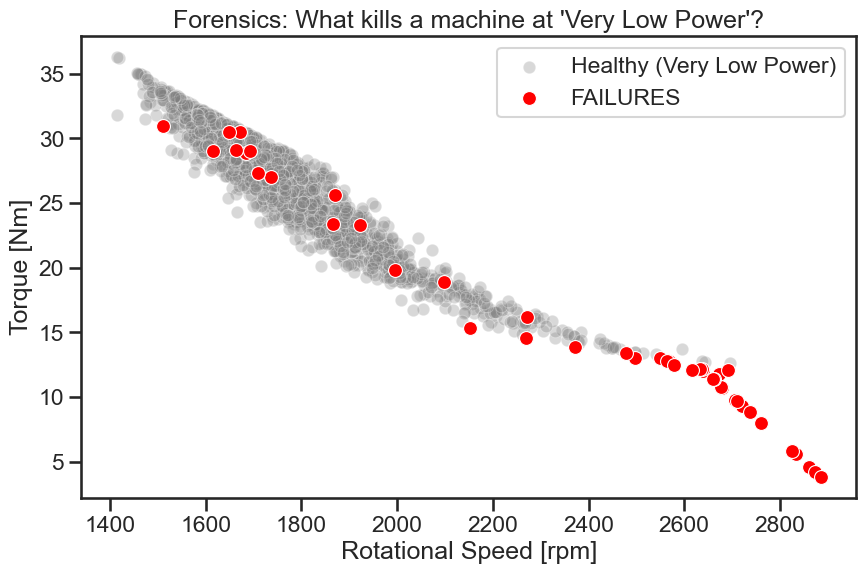

In [13]:
# ==========================================
# INVESTIGATION: CRACKING THE "LOW POWER" BIN
# ==========================================

# 1. Isolate the "Very Low" power data
low_power_df = df[df['Power_Bin'] == 'Very Low']

print(f"Analyzing {len(low_power_df)} records in the 'Very Low' Power Bin...")

# 2. Scatter Plot: Speed vs Torque (INSIDE this bin only)
plt.figure(figsize=(10, 6))

# Plot Healthy (Grey)
sns.scatterplot(
    data=low_power_df[low_power_df['Machine_Failure'] == 0], 
    x='Rotational_Speed', 
    y='Torque', 
    color='grey', 
    alpha=0.3, 
    label='Healthy (Very Low Power)'
)

# Plot Failures (Red)
sns.scatterplot(
    data=low_power_df[low_power_df['Machine_Failure'] == 1], 
    x='Rotational_Speed', 
    y='Torque', 
    color='red', 
    s=100, 
    label='FAILURES'
)

plt.title("Forensics: What kills a machine at 'Very Low Power'?")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.legend()
plt.show()